# Problem Statement:
## Use Euler's Method to solve the differential equation  
$$\frac{dx}{dt} = -x^3 + \sin(t)$$  
with initial condition $x = 0$ at $t = 0$.

*Source: Mark Newman, Computational Physics (1st Edition)*

## We will demonstrate 2 versions of Euler's Method:
* Version 1. Author **Newman's original** version as covered in his textbook.
* Version 2. A **modern version** using updated syntax.

# Version 1. Baseline Implementation (Newman, 2013)
*Source: Mark Newman, Computational Physics (1st Edition), https://websites.umich.edu/~mejn/cp2/programs/euler.py*  

The code in this cell is taken from Newman's website linked above.

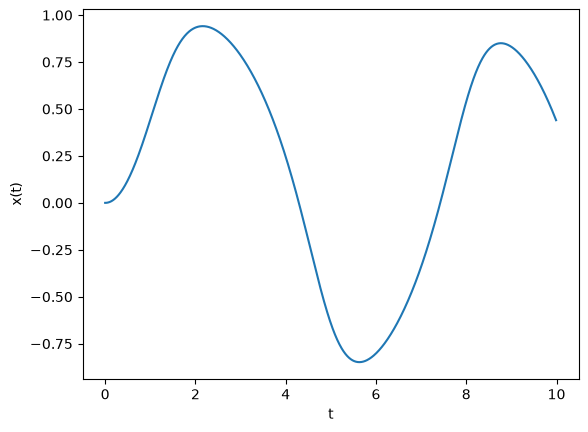

In [1]:
from math import sin
from numpy import arange
import matplotlib.pyplot as plt

def f(x,t):
    return -x**3 + sin(t)

a = 0.0           # Start of the interval
b = 10.0          # End of the interval
N = 1000          # Number of steps
h = (b-a)/N       # Size of a single step
x = 0.0           # Initial condition

tpoints = arange(a,b,h)
xpoints = []
for t in tpoints:
    xpoints.append(x)
    x += h*f(x,t)

plt.plot(tpoints,xpoints)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.show()

# Version 2. Euler's Method using modernized syntax.
### Improvements
1. Used **`np.linspace` instead of `np.arange`** to prevent off-by-one errors in the $t$-axis caused by  floating-point step drift. This guarantees an exact array size `n_steps`. 
2. Used **Matplotlib object-oriented API (`fig`, `ax`)** instead of the stateful `pyplot` interface. Explicit `Figure` and `Axes` instances offer better control, readability, and scalability when handling complex or multi-panel plots.
3. Used explicit **type hints** to clarify the expected data types of function arguments and return values.
4. **Pre-allocated memory** with `np.empty` to improve performance. The old way initialized an empty array `x_points = []` and appended to it inside a 1,000-step loop.
5. **Encapsulation and reusability** improvements: put the solver inside a function and prevented Matplotlib from drawing plots if the code were imported into another program.

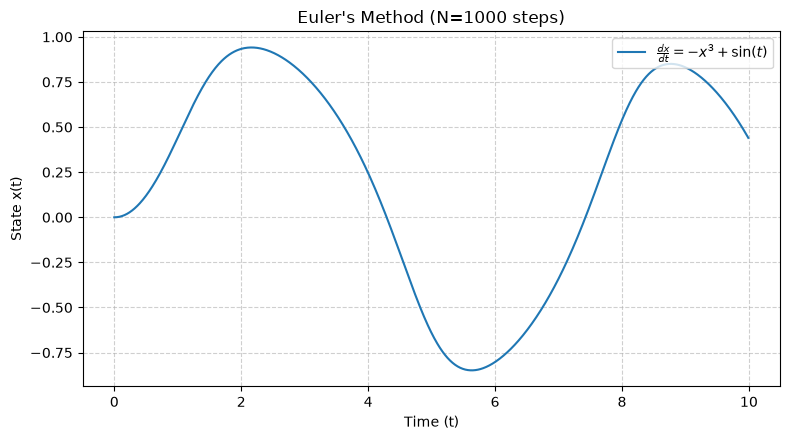

In [2]:
# Version 2: Euler's Method using modernized syntax.

from typing import Tuple
import matplotlib.pyplot as plt
import numpy as np

def f(x: float | np.ndarray, t: float | np.ndarray) -> float | np.ndarray:
    """Calculates the right-hand side of the ODE dx/dt = f(x, t) where f(x, t) = -x^3 + sin(t)."""
    return -(x**3) + np.sin(t)


def solve_euler_modern(
    t_start: float = 0.0,
    t_end: float = 10.0,
    n_steps: int = 1000,
    x0: float = 0.0,
) -> Tuple[np.ndarray, np.ndarray]:
    """Uses Euler's method to solve ODE dx/dt = f(x, t) where f(x, t) is defined in the function above.
    Returns Tuple[time points array, solved values x(t) array].
    """

    # Use linspace to prevent off-by-one errors caused by floating-point step drift
    t_points, h = np.linspace(t_start, t_end, n_steps, retstep=True, endpoint=False)

    # Pre-allocate memory to avoid list append overhead
    x_points = np.empty(n_steps, dtype=np.float64)
    
    x = x0
    for i, t in enumerate(t_points):
        x_points[i] = x
        x += h * f(x, t)
        
    return t_points, x_points


if __name__ == "__main__":
    t_points, x_points = solve_euler_modern()
    
    # Modern object-oriented Matplotlib API
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(t_points, x_points, label=r"$\frac{dx}{dt} = -x^3 + \sin(t)$", color="tab:blue")
    ax.set_title(f"Euler's Method (N={len(t_points)} steps)")
    ax.set_xlabel("Time (t)")
    ax.set_ylabel("State x(t)")
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()